In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')

In [ ]:
# First look at the data
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
# now look at
print(df.shape)

(200, 5)


In [ ]:
# now look at
print(df.dtypes)


CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


In [ ]:
# now look at
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
# now look at
print(df.tail())

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


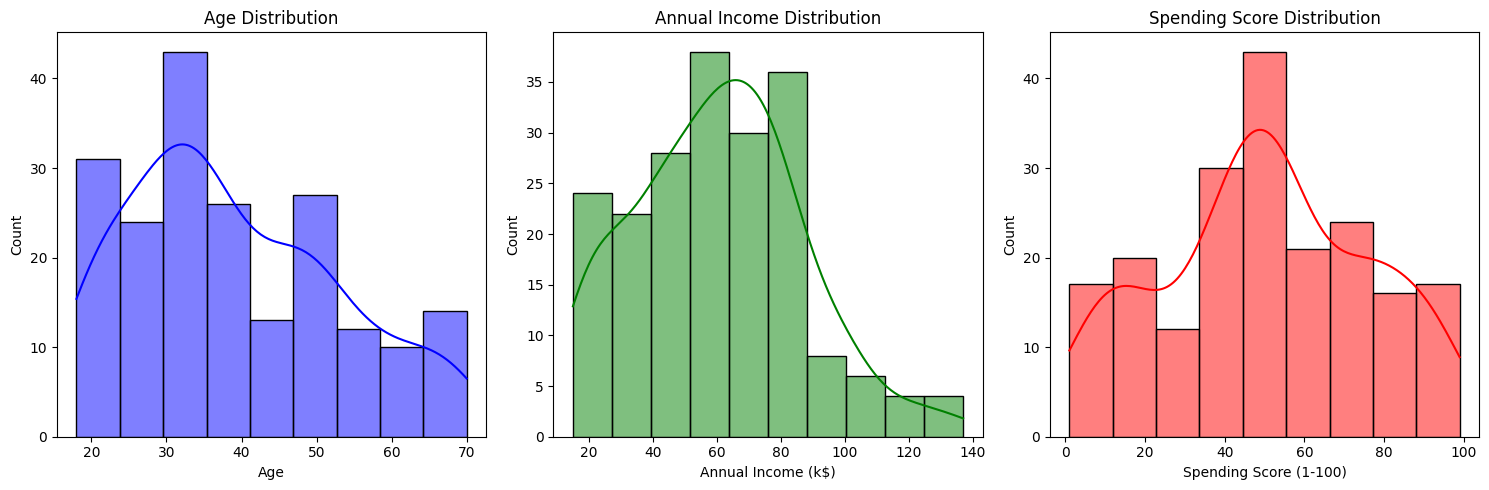

In [ ]:
# Help me to run this code for visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(df['Age'], ax=axes[0], kde=True, color='blue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], ax=axes[1], kde=True, color='green')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], ax=axes[2], kde=True, color='red')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

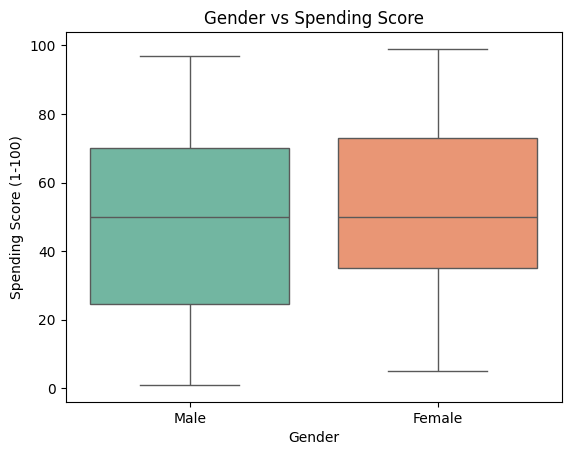

In [ ]:
# Help me to run this code for visualization
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df, palette='Set2')
plt.title('Gender vs Spending Score')
plt.show()


In [ ]:
# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.head())

   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


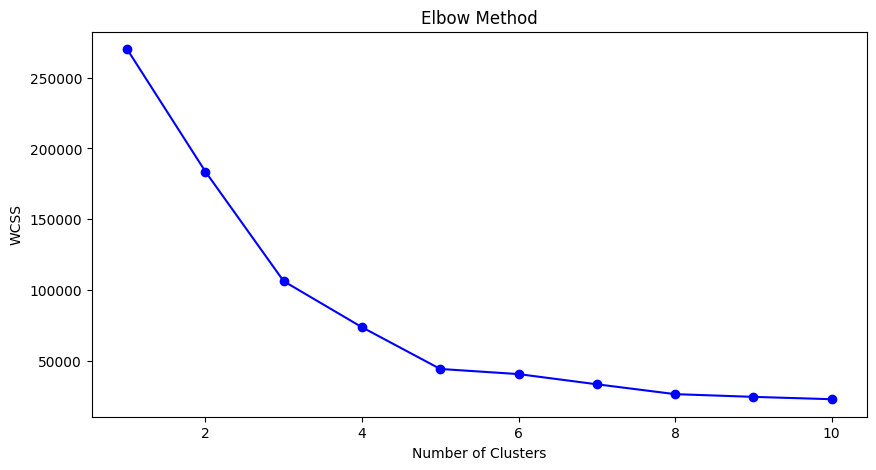

In [ ]:
# now do the Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', color='blue')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
# now do the Silhouette Score
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f'Number of clusters: {i}, Silhouette Score: {score:.4f}')


Number of clusters: 2, Silhouette Score: 0.3956
Number of clusters: 3, Silhouette Score: 0.4676
Number of clusters: 4, Silhouette Score: 0.4938
Number of clusters: 5, Silhouette Score: 0.5539
Number of clusters: 6, Silhouette Score: 0.5128
Number of clusters: 7, Silhouette Score: 0.5017
Number of clusters: 8, Silhouette Score: 0.4963
Number of clusters: 9, Silhouette Score: 0.4559
Number of clusters: 10, Silhouette Score: 0.4426


In [ ]:
# Help mke to build the K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

# Fit the model and assign cluster labels
df['Cluster'] = kmeans.fit_predict(X)

# See how many customers are in each cluster
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


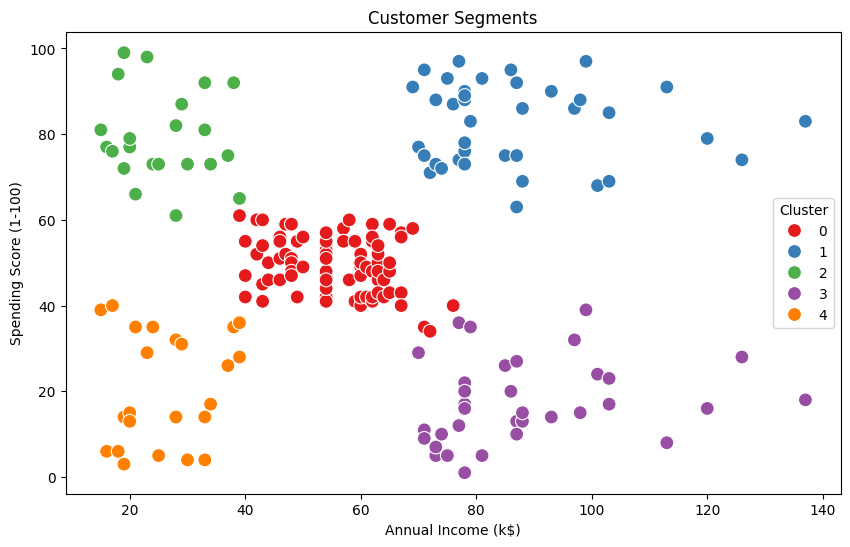

In [ ]:
# now visualize the clusters
plt.figure(figsize=(10, 6))

sns.scatterplot(x=df['Annual Income (k$)'],
                y=df['Spending Score (1-100)'],
                hue=df['Cluster'],
                palette='Set1',
                s=100)

plt.title('Customer Segments')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

# **Cluster Interpretation**

Cluster 0 — Average Customers (81 customers)
This is the largest group with 81 customers. These customers earn an average income and also spend an average amount. They are the normal everyday shoppers that you will find in any mall.



Cluster 1 — High Income High Spenders (39 customers)
These customers earn a lot of money and they also spend a lot. This group is very important to the mall because they bring in the most money. The mall should focus on keeping this group happy.


Cluster 2 — Low Income High Spenders (22 customers)
This group is very interesting. These customers do not earn much money but they still spend a lot. They might be young people or people who just love shopping no matter what.


Cluster 3 — Low Income Low Spenders (35 customers)
These customers do not earn much and they do not spend much either. They are very careful with their money and only buy what they really need.


Cluster 4 — High Income Low Spenders (23 customers)
This is the most surprising group. These customers earn a lot of money but they barely spend anything in the mall. They are rich but very conservative with their money.